In [1]:
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from pathlib import Path
import plotly.express as px
import igraph as ig
from pathlib import Path
import joblib
import pickle, gzip
import ast
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from collections import Counter
from collections import defaultdict
import sys


import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# The visualizations created are saved to the images folder
ROOT_FIGURES_DIR = '../images/'

In [3]:
# Obtained from 01_publication_classification
ROOT_DISAMBIGUATED_CLASSIFICATION_DIR = '../data/open_alex_matches/'
matches_df = pd.read_csv(ROOT_DISAMBIGUATED_CLASSIFICATION_DIR + '/matches.csv.gz', engine = 'python', compression="gzip")

# The visualizations created are saved to the images folder if the constact is enabled.
ROOT_VECTOR_COMPARISON_DIR = '../data/vector_comparison/'

In [4]:
# version 2025aug Oct 29, 2025. zenedo: 10.5281/zenodo.17442025
ROOT_CLASSIFICATION_DIR = '../data/classification_openalex_2025/'
micro_cluster_path = ROOT_CLASSIFICATION_DIR + 'micro_cluster.tsv'
micro_cluster_df = pd.read_csv(micro_cluster_path, sep =  '\\t', engine='python')

In [5]:
ROOT_VECTOR_EMBEDDINGS_DIR = Path("../data/vector/")

In [6]:
community_summary_df = pd.read_csv("../data/leiden/community_summary.csv.gz", compression="gzip")

# The columns have to be converted back into dictionaries when it has been read out. 
dict_columns = ['software_freq', 'doi_freq', 'macro_cluster_freq', 
                'meso_cluster_freq', 'micro_cluster_freq', 'main_field_freq']

for col in dict_columns:
    community_summary_df[col] = community_summary_df[col].apply(ast.literal_eval)

In [7]:
agg_test_df = pd.read_csv(ROOT_VECTOR_EMBEDDINGS_DIR / "agg_test_df.csv.gz", engine='python', compression='gzip')

agg_test_df['software_list'] = agg_test_df['software_list'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

In [ ]:
train_embeddings = pd.read_csv(ROOT_VECTOR_EMBEDDINGS_DIR / "train_embeddings.csv.gz", engine='python', compression='gzip')
test_embeddings = pd.read_csv(ROOT_VECTOR_EMBEDDINGS_DIR / "test_embeddings.csv.gz", engine='python', compression='gzip')

def parse_embedding(val):
    if isinstance(val, np.ndarray):
        return val
    return np.fromstring(val.strip("[]"), sep=" ")

train_embeddings['abs_embedding'] = train_embeddings['abs_embedding'].apply(parse_embedding)
test_embeddings['abs_embedding'] = test_embeddings['abs_embedding'].apply(parse_embedding)


In [9]:
test_embeddings = test_embeddings.merge(
    matches_df[['doi', 'macro_cluster_id', 'meso_cluster_id', 'micro_cluster_id']],
    on='doi',
    how='left'
)
test_embeddings

,doi,abs_embedding,macro_cluster_id,meso_cluster_id,micro_cluster_id
0,10.1099/mgen.0.000161,"[0.0281690732, -0.0777003244, -0.0447983518, 0...",4,174,486
1,10.1016/j.celrep.2018.08.010,"[-0.0212364309, -0.063418515, -0.0717834383, 0...",3,6,581
2,10.3389/fnhum.2015.00077,"[0.0455544591, 0.0286879353, -0.0550108775, 0....",3,6,427
3,10.3390/ijms19103049,"[0.0443590581, -0.0646726415, -0.0466362573, -...",1,153,123
4,10.1007/s00266-018-1298-4,"[0.00428551855, 0.0458282083, -0.0523110405, 0...",15,691,1322
...,...,...,...,...,...
187344,10.3897/zookeys.463.8397,"[-0.0100124562, -0.0482294597, -0.0320331566, ...",4,11,895
187345,10.3390/ijms20112636,"[-0.0171696562, -0.0290033221, -0.0917966068, ...",1,224,176
187346,10.1371/journal.pone.0048687,"[0.0494167469, -0.0891364515, 0.0578807518, 0....",1,266,261
187347,10.1016/j.bbr.2016.03.015,"[0.011814977, -0.0169856064, -0.0285508055, 0....",1,132,1685


In [10]:
train_embeddings = train_embeddings.merge(
    matches_df[['doi', 'macro_cluster_id', 'meso_cluster_id', 'micro_cluster_id']],
    on='doi',
    how='left'
)

def distinction_set(train_embeddings, test_embeddings) -> tuple[set, set]:
    micro_in_training = set(train_embeddings['micro_cluster_id'])
    micro_in_test     = set(test_embeddings['micro_cluster_id'])

    exclusive_in_training = micro_in_training - micro_in_test  # only in train
    exclusive_in_test     = micro_in_test - micro_in_training  # only in test

    return exclusive_in_training, exclusive_in_test

exclusive_train, exclusive_test = distinction_set(train_embeddings, test_embeddings)
print(f"Micro clusters only in train : {len(exclusive_train)}")
print(f"Micro clusters only in test  : {len(exclusive_test)}")
print(f"Shared                       : {len(set(train_embeddings['micro_cluster_id']) & set(test_embeddings['micro_cluster_id']))}")

Micro clusters only in train : 533
Micro clusters only in test  : 87
Shared                       : 2772


In [11]:
print(len(train_embeddings))
print(len(test_embeddings))

749549
187349


In [ ]:
class MicroClusterFrequencyComparer:
    def __init__(
        self,
        community_summary_df: pd.DataFrame,
        micro_cluster_df: pd.DataFrame,
        matches_df: pd.DataFrame,
        save_dir: str | None = None,
    ):
        self.df = community_summary_df
        self.micro_cluster_df = micro_cluster_df
        self.matches_df = matches_df
        self.save_dir = Path(save_dir) if save_dir else None
        self._micro_cluster_to_community = None  # built lazily on first use

    def _sort_communities(self, sort_by: list[str], top_n: int) -> pd.DataFrame:
        return (
            self.df
            .sort_values(sort_by, ascending=False)
            .head(top_n)
        )

    def _find_micro_cluster_label(self, cluster_id: int) -> str:
        """
        Resolve a micro cluster id to its short label, with the id appended
        to ensure uniqueness when multiple cluster ids share the same label.
        """
        label = self.micro_cluster_df[
            self.micro_cluster_df['micro_cluster_id'] == cluster_id
        ]['short_label'].iloc[0]
        return f"{label} (id={cluster_id})"

    def _build_micro_cluster_to_community(self):
        """
        mapping of micro_cluster_id -> community_id -> set of DOIs.
        """
        if self._micro_cluster_to_community is not None:
            return self._micro_cluster_to_community

        doi_to_micro_cluster_id = (
            self.matches_df
            .groupby('doi')['micro_cluster_id']
            .apply(set)
            .to_dict()
        )

        micro_cluster_to_community = {}

        for _, comm_row in self.df.iterrows():
            community = comm_row['community']
            dois = comm_row['doi_freq'].keys()

            for doi in dois:
                micro_cluster_ids = doi_to_micro_cluster_id.get(doi, set())

                for micro_id in micro_cluster_ids:
                    micro_id = str(micro_id)

                    if micro_id not in micro_cluster_to_community:
                        micro_cluster_to_community[micro_id] = {community: {doi}}
                    elif community not in micro_cluster_to_community[micro_id]:
                        micro_cluster_to_community[micro_id][community] = {doi}
                    else:
                        micro_cluster_to_community[micro_id][community].add(doi)

        self._micro_cluster_to_community = micro_cluster_to_community
        return self._micro_cluster_to_community
    
    def has_assigned_community_highest_frequency(self, assigned_community, micro_cluster_id) -> tuple[bool, int, int, int]:
        micro_cluster_id = str(micro_cluster_id)

        mapping = self._build_micro_cluster_to_community()

        # for example, '21': {'doi_1', ..., 'doi_350'}, '59': {'doi_351', ..., 'doi_380'}
        # default to empty dictionary (no community has it)
        micro_cluster_frequencies = mapping.get(micro_cluster_id, {})

        if not micro_cluster_frequencies:
            return False, None, 0, 0 # not a single community has that frequency

        best_community = max(micro_cluster_frequencies, key=lambda c: len(micro_cluster_frequencies[c]))

        best_freq = len(micro_cluster_frequencies[best_community])
        assigned_freq = len(micro_cluster_frequencies.get(assigned_community, set()))
        
        return int(assigned_community) == best_community, best_community, assigned_freq, best_freq
    
    def has_assigned_community_highest_ratio(self, assigned_community, micro_cluster_id) -> tuple[bool, int, float, float]:
        """
        Returns (is_best_fit, best_community_id, assigned_ratio, best_ratio) for a given predicted community and micro cluster id.
        """
        micro_cluster_id = str(micro_cluster_id)

        mapping = self._build_micro_cluster_to_community()

        micro_cluster_frequencies = mapping.get(micro_cluster_id, {})

        if not micro_cluster_frequencies:
            return False, None, 0.0, 0.0

        doi_counts = self.df.set_index('community')['doi_count'].to_dict()

        def get_ratio(community):
            freq = len(micro_cluster_frequencies.get(community, set()))
            total = doi_counts.get(community, 1)  # fallback to 1 to avoid division by zero
            return freq / total

        best_community = max(micro_cluster_frequencies, key=get_ratio)

        best_ratio = get_ratio(best_community)
        assigned_ratio = get_ratio(assigned_community)

        return int(assigned_community) == best_community, best_community, assigned_ratio, best_ratio


    def _get_freq_dict(self, community: int, column: str) -> dict | None:
        """
        Retrieve the frequency dict for a given community and column.
        """
        if community < 0:
            raise ValueError("community must be >= 0")

        if not hasattr(self.df, "columns") or column not in self.df.columns or "community" not in self.df.columns:
            raise ValueError(f"DataFrame must contain columns: {{'community', '{column}'}}")

        matches = self.df.loc[self.df["community"] == community, column]

        if matches.empty:
            return None

        target_dict = matches.iloc[0]

        if target_dict is None:
            return None
        if not hasattr(target_dict, "__contains__") or not hasattr(target_dict, "get"):
            raise ValueError(f"'{column}' must be a dict-like object")

        return target_dict

    def get_micro_cluster_freq_in_community(self, community: int, target_micro_id: int) -> int:
        """
        Get the frequency of a specific micro cluster within a given community.
        """
        if target_micro_id < 0:
            raise ValueError("target_micro_id must be >= 0")

        target_dict = self._get_freq_dict(community, "micro_cluster_freq")

        if target_dict is None:
            return -1

        return target_dict.get(target_micro_id, -1)
    
frequency_comparer = MicroClusterFrequencyComparer(
    community_summary_df=community_summary_df,
    micro_cluster_df=micro_cluster_df,
    matches_df=matches_df,
    save_dir=ROOT_VECTOR_COMPARISON_DIR,
)


In [ ]:
class MicroClusterRankComparer:
    """
    If the assigned to community has that micro cluster occur higher in its relative
    rank than any other community than the assigned community would be the best
    fit.
    """
    def __init__(self, community_summary_df: pd.DataFrame,):
        self.df = community_summary_df
        self._micro_cluster_rank_cache = self._build_micro_cluster_rank_cache()

    def _build_micro_cluster_rank_cache(self) -> dict:
        """
        precomputing rank maps for all communities.
        cache structure: {community_id: {micro_cluster_id: rank}}
        """
        cache = {}
        for _, row in self.df.iterrows():
            community = row['community']
            micro_cluster_freq = row['micro_cluster_freq']
            
            sorted_clusters = sorted(micro_cluster_freq.items(), key=lambda x: x[1], reverse=True)
            cache[community] = {cluster_id: rank + 1 for rank, (cluster_id, _) in enumerate(sorted_clusters)}
        
        return cache

    def get_best_community_by_micro_cluster_rank(self, predicted_community: int, micro_cluster_id: int) -> tuple[bool, int, int, int]:
        """
        returns (is_best_fit, best_community_id, predicted_rank, best_rank) for a given predicted community and micro cluster id.
        """
        best_community = min(
            self._micro_cluster_rank_cache.keys(),
            key=lambda community: self._micro_cluster_rank_cache[community].get(micro_cluster_id, sys.maxsize)
        )
        
        predicted_rank = self._micro_cluster_rank_cache[predicted_community].get(micro_cluster_id, sys.maxsize)
        best_rank = self._micro_cluster_rank_cache[best_community].get(micro_cluster_id, sys.maxsize)
        
        return predicted_community == best_community, best_community, predicted_rank, best_rank
    
rank_comparer = MicroClusterRankComparer(
    community_summary_df=community_summary_df,
)



In [ ]:
def get_community_centres(community_summary_df, train_embeddings):
    community_means = {}

    for i, row in community_summary_df.iterrows():
        community_index = row['community']
        

        dois_set = set(list(row['doi_freq'].keys()))
        abstract_embeddings = train_embeddings[train_embeddings['doi'].isin(dois_set)]

        if abstract_embeddings.empty:
            print(f"Warning: no training embeddings found for community {community_index}, setting to zero vector.")
            embedding_dim = len(train_embeddings['abs_embedding'].iloc[0])
            community_means[community_index] = np.zeros(embedding_dim)
            continue

        matrix = np.vstack(abstract_embeddings["abs_embedding"].values)

        centroid = matrix.mean(axis=0)                 

        community_means[community_index] = centroid
    
    return community_means


def assign_predicted_community(train_embeddings, community_means):
    community_labels = list(community_means.keys())
    community_matrix = np.vstack(list(community_means.values()))  

    doc_matrix = np.vstack(train_embeddings['abs_embedding'].values)

    sims = cosine_similarity(doc_matrix, community_matrix)
    closest_idx = np.argmax(sims, axis=1)

    train_embeddings['predicted_community'] = [community_labels[i] for i in closest_idx]
    return train_embeddings
  
means = get_community_centres(community_summary_df=community_summary_df, train_embeddings=train_embeddings)
test_embeddings = assign_predicted_community(test_embeddings, means)

In [ ]:
class CommunityAssignmentEvaluator:
    def __init__(
        self,
        frequency_comparer,
        rank_comparer,
        community_summary_df: pd.DataFrame,
        agg_test_df: pd.DataFrame,
        save_dir: str | None = None,
    ):
        self.frequency_comparer   = frequency_comparer
        self.rank_comparer        = rank_comparer
        self.community_summary_df = community_summary_df
        self.agg_test_df          = agg_test_df
        self.save_dir = Path(save_dir) if save_dir else None

        self.results_df  = None
        self.metrics     = {}

    def evaluate(self, test_df: pd.DataFrame) -> pd.DataFrame:
        """
        Run all three metrics for every row in test_df.
        test_df must have columns: ['doi', 'predicted_community', 'micro_cluster_id']
        """
        rows = []

        for _, row in test_df.iterrows():
            predicted = int(row['predicted_community'])
            micro_id  = int(row['micro_cluster_id'])

            # Best fitting functions based on my three metrics
            # Note to self, ratio is comparible with rank and needs to be noted in the thesis
            is_best_freq,  best_comm_freq,  assigned_freq,  best_freq  = self.frequency_comparer.has_assigned_community_highest_frequency(predicted, micro_id)
            is_best_ratio, best_comm_ratio, assigned_ratio, best_ratio = self.frequency_comparer.has_assigned_community_highest_ratio(predicted, micro_id)
            is_best_rank,  best_comm_rank,  predicted_rank, best_rank  = self.rank_comparer.get_best_community_by_micro_cluster_rank(predicted, micro_id)

            # software match of the predicted cluster
            doi_software = self.agg_test_df.loc[self.agg_test_df['doi'] == row['doi'], 'software_list']
            paper_software = set(doi_software.iloc[0]) if not doi_software.empty and isinstance(doi_software.iloc[0], list) else set()

            community_row = self.community_summary_df[
                self.community_summary_df['community'] == predicted
            ]
            community_sw_set = set(community_row.iloc[0]['software_freq'].keys()) if not community_row.empty else set()

            matched_software   = paper_software & community_sw_set
            unmatched_software = paper_software - community_sw_set

            # Four generic grouping in rows.
            # The first group is the paper and its expected community and the software found in the community
            # The second is the best fit using frequency
            # The third  is the best fit using ratio
            # The fourth is the best fit using rank
            rows.append({
                'doi':                row['doi'],
                'predicted_community': predicted,
                'micro_cluster_id':   micro_id,
                'paper_software':              list(paper_software),
                'matched_software':            list(matched_software),
                'unmatched_software':          list(unmatched_software),
                'matched_sw_communities':      {sw: predicted for sw in matched_software},
                'dominant_community':          predicted if matched_software else None,
                'dominant_community_software': list(community_sw_set),
                'software_match_count':        len(matched_software),
                'software_match_ratio':        len(matched_software) / len(paper_software) if paper_software else 0.0,

                'is_best_freq':       is_best_freq,
                'best_comm_freq':     best_comm_freq,
                'assigned_freq':      assigned_freq,
                'best_freq':          best_freq,

                'is_best_ratio':      is_best_ratio,
                'best_comm_ratio':    best_comm_ratio,
                'assigned_ratio':     assigned_ratio,
                'best_ratio':         best_ratio,

                'is_best_rank':       is_best_rank,
                'best_comm_rank':     best_comm_rank,
                'predicted_rank':     predicted_rank,
                'best_rank':          best_rank,
            })

        self.results_df = pd.DataFrame(rows)
        self._save(self.results_df, 'evaluation_results.csv.gz')
        return self.results_df

    def compute_all_metrics(self) -> pd.DataFrame:
        if self.results_df is None:
            raise Exception("results have not yet been generated. Make sure to run 'evaluate' first.") 

        rows = []
        community_counts_per_metric = {}

        for metric, is_best_col, best_community_col in [
            ('frequency', 'is_best_freq',  'best_comm_freq'),
            ('ratio',     'is_best_ratio', 'best_comm_ratio'),
            ('rank',      'is_best_rank',  'best_comm_rank'),
        ]:
            correct_df = self.results_df[self.results_df[is_best_col] == True]
            community_counts = correct_df[best_community_col].value_counts()
            community_counts_per_metric[metric] = community_counts

            correct  = self.results_df[is_best_col].sum()
            total    = len(self.results_df)
            accuracy = correct / total if total > 0 else 0.0
            community_ratios = (community_counts / correct).round(4).to_dict()

            communities = set(self.results_df['predicted_community']) | set(self.results_df[best_community_col].dropna())
            per_community = []
            for community in communities:
                tp = len(self.results_df[(self.results_df['predicted_community'] == community) & (self.results_df[is_best_col] == True)])
                fp = len(self.results_df[(self.results_df['predicted_community'] == community) & (self.results_df[is_best_col] == False)])
                fn = len(self.results_df[(self.results_df['predicted_community'] != community) & (self.results_df[best_community_col] == community)])
                per_community.append({'tp': tp, 'fp': fp, 'fn': fn})

            per_community_df = pd.DataFrame(per_community)
            total_tp = per_community_df['tp'].sum()
            total_fp = per_community_df['fp'].sum()
            total_fn = per_community_df['fn'].sum()

            precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
            recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
            f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

            rows.append({
                'metric':           metric,
                'correct':          correct,
                'total':            total,
                'accuracy':         accuracy,
                'tp':               total_tp,
                'fp':               total_fp,
                'fn':               total_fn,
                'precision':        precision,
                'recall':           recall,
                'f1':               f1,
                'community_ratios': community_ratios,
            })

            print(f"  {metric:10s}: Accuracy: {accuracy:.4f} ({correct}/{total})")
            print(f"             Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
            for community, ratio in sorted(community_ratios.items(), key=lambda x: x[1], reverse=True):
                print(f"    community {community}: {ratio:.4f} ({community_counts[community]}/{correct})")

        self.metrics = pd.DataFrame(rows).set_index('metric')

        summary_df = self.metrics.drop(columns='community_ratios').reset_index()
        self._save(summary_df, 'metrics_summary.csv.gz')

        for metric, row in self.metrics.iterrows():
            community_counts = community_counts_per_metric[metric]
            records = [
                {
                    'community': community,
                    'correct_count': community_counts[community],
                    'ratio_of_correct': ratio,
                }
                for community, ratio in row['community_ratios'].items()
            ]
            community_df = (
                pd.DataFrame(records)
                .sort_values('ratio_of_correct', ascending=False)
            )
            self._save(community_df, f'metrics_community_ratios_{metric}.csv.gz')

        return self.metrics

    def _save(self, df: pd.DataFrame, filename: str):
        df.to_csv(self.save_dir / filename, index=False, compression="gzip")


evaluator = CommunityAssignmentEvaluator(
    frequency_comparer=frequency_comparer,
    rank_comparer=rank_comparer,
    community_summary_df=community_summary_df,
    agg_test_df=agg_test_df,
    save_dir=ROOT_VECTOR_COMPARISON_DIR,
)

results_df = evaluator.evaluate(test_embeddings)
metrics    = evaluator.compute_all_metrics()

  frequency : Accuracy: 0.1985 (37197/187349)
             Precision: 0.1985  Recall: 0.1987  F1: 0.1986
    community 0.0: 0.3274 (12177/37197)
    community 1.0: 0.2652 (9863/37197)
    community 65.0: 0.0452 (1682/37197)
    community 48.0: 0.0432 (1606/37197)
    community 87.0: 0.0404 (1501/37197)
    community 95.0: 0.0290 (1077/37197)
    community 102.0: 0.0263 (979/37197)
    community 51.0: 0.0254 (944/37197)
    community 49.0: 0.0234 (871/37197)
    community 88.0: 0.0224 (833/37197)
    community 3.0: 0.0212 (788/37197)
    community 50.0: 0.0178 (662/37197)
    community 66.0: 0.0153 (570/37197)
    community 54.0: 0.0142 (527/37197)
    community 100.0: 0.0106 (394/37197)
    community 94.0: 0.0103 (383/37197)
    community 64.0: 0.0083 (307/37197)
    community 52.0: 0.0065 (242/37197)
    community 2.0: 0.0057 (213/37197)
    community 96.0: 0.0051 (188/37197)
    community 47.0: 0.0050 (185/37197)
    community 53.0: 0.0049 (183/37197)
    community 110.0: 0.0044 (163

In [ ]:
evaluation = pd.read_csv(ROOT_VECTOR_COMPARISON_DIR + 'evaluation_results.csv.gz', compression="gzip")

In [21]:
evaluation

,doi,predicted_community,micro_cluster_id,paper_software,matched_software,unmatched_software,matched_sw_communities,dominant_community,dominant_community_software,software_match_count,...,assigned_freq,best_freq,is_best_ratio,best_comm_ratio,assigned_ratio,best_ratio,is_best_rank,best_comm_rank,predicted_rank,best_rank
0,10.1099/mgen.0.000161,88,486,"['RAxML', 'BLASTN', 'EasyFig', 'SPAdes', 'RAST...","['EasyFig', 'SPAdes', 'RASTtk', 'ABACAS', 'Vel...","['RAxML', 'BLASTN', 'jModelTest', 'Local Blast...","{'EasyFig': 88, 'SPAdes': 88, 'RASTtk': 88, 'A...",88.0,"['DBLMSP', 'Pbdagcon', 'meta_rna', 'Micrograph...",7,...,637,637,True,88.0,0.019045,0.019045,True,88,7,7
1,10.1016/j.celrep.2018.08.010,48,581,"['MATLAB', 'LabVIEW']","['MATLAB', 'LabVIEW']",[],"{'MATLAB': 48, 'LabVIEW': 48}",48.0,"['psignifit', 'Hex-o-Spell', 'CNS Vital Signs'...",2,...,904,904,False,52.0,0.012444,0.016179,True,48,4,4
2,10.3389/fnhum.2015.00077,48,427,"['MATLAB', 'Psychophysics Toolbox']","['Psychophysics Toolbox', 'MATLAB']",[],"{'Psychophysics Toolbox': 48, 'MATLAB': 48}",48.0,"['psignifit', 'Hex-o-Spell', 'CNS Vital Signs'...",2,...,813,813,True,48.0,0.011192,0.011192,True,48,7,7
3,10.3390/ijms19103049,101,123,"['MATLAB', 'ImageQuant']",[],"['MATLAB', 'ImageQuant']",{},NaN,['ARLO (Automated Recognition with Layered Opt...,0,...,315,1686,False,11.0,0.012758,0.043478,False,10,8,3
4,10.1007/s00266-018-1298-4,48,1322,"['SPSS', 'ImageJ']",[],"['SPSS', 'ImageJ']",{},NaN,"['psignifit', 'Hex-o-Spell', 'CNS Vital Signs'...",0,...,4,28,False,13.0,0.000055,0.062500,False,13,1527,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187344,10.3897/zookeys.463.8397,47,895,"['Pentaho Data Integration', 'BioCASe', 'PageB...","['Pentaho Data Integration', 'BioCASe']","['Analytica', 'PageBreakin', 'Pentaho Data Int...","{'Pentaho Data Integration': 47, 'BioCASe': 47}",47.0,"['Arena-Idb', 'Genetta Soft', 'Go Ethereum', '...",2,...,167,786,False,66.0,0.004245,0.037608,False,66,31,1
187345,10.3390/ijms20112636,4,176,"['SPSS', 'NIS-Elements']",[],"['SPSS', 'NIS-Elements']",{},NaN,"['Galaxie chromatography manager', 'Bruker mic...",0,...,55,2873,False,15.0,0.022035,0.066667,False,1,5,2
187346,10.1371/journal.pone.0048687,95,261,"['smartpca', 'R', 'PLINK', 'SIFT', 'browser', ...","['smartpca', 'PLINK']","['browser', 'R', 'SIFT', 'PolyPhen']","{'smartpca': 95, 'PLINK': 95}",95.0,"['SiPhy cons', 'S.A.S', 'ALCHEMY', 'TATES', 'P...",2,...,3260,3260,False,78.0,0.137768,1.000000,False,78,1,1
187347,10.1016/j.bbr.2016.03.015,48,1685,"['EthoVision XT', 'SPSS']",[],"['EthoVision XT', 'SPSS']",{},NaN,"['psignifit', 'Hex-o-Spell', 'CNS Vital Signs'...",0,...,150,595,False,97.0,0.002065,0.006018,False,97,89,21


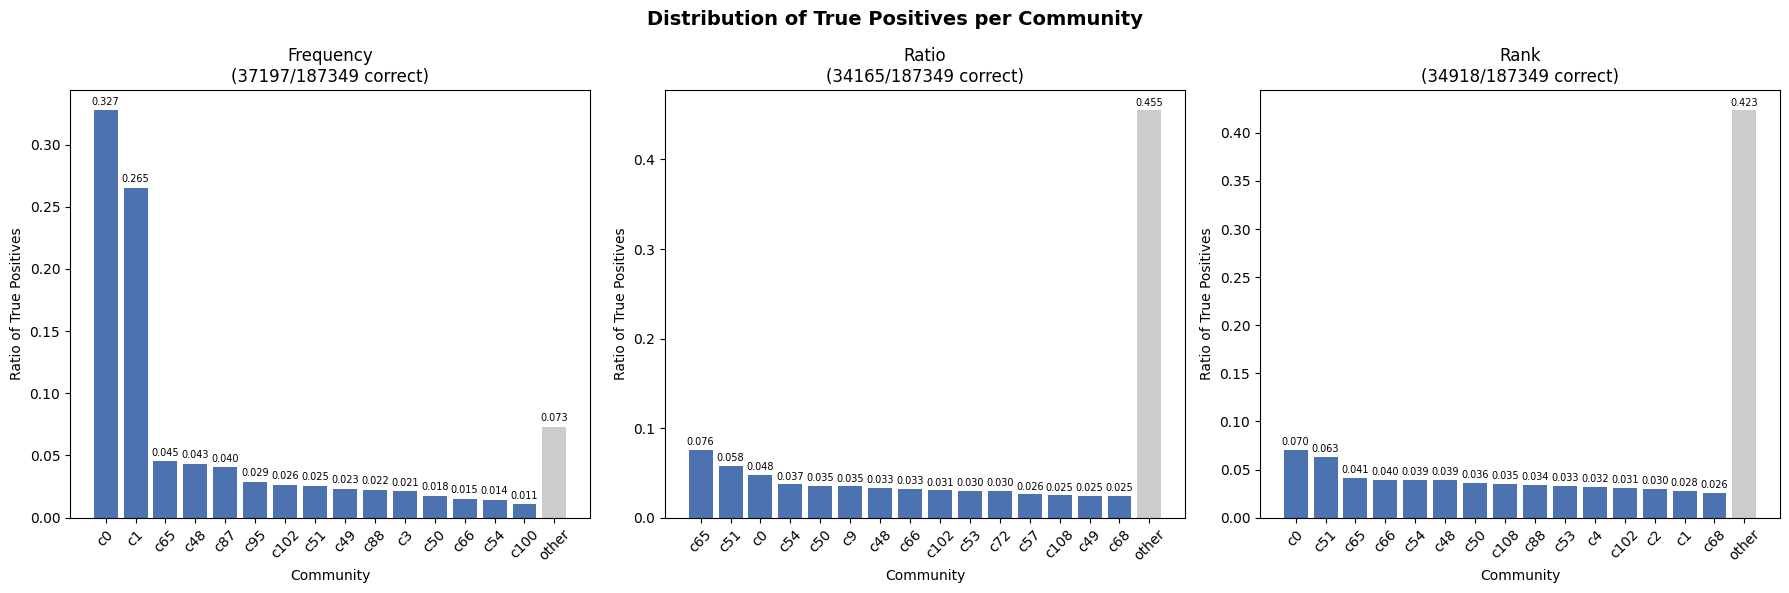

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

evaluation = pd.read_csv(ROOT_VECTOR_COMPARISON_DIR + 'evaluation_results.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metric, is_best_col, best_community_col) in zip(axes, [
    ('Frequency', 'is_best_freq',  'best_comm_freq'),
    ('Ratio',     'is_best_ratio', 'best_comm_ratio'),
    ('Rank',      'is_best_rank',  'best_comm_rank'),
]):
    correct_df = evaluation[evaluation[is_best_col] == True]
    community_counts = correct_df[best_community_col].value_counts()
    community_ratios = (community_counts / len(correct_df)).sort_values(ascending=False)

    # Top N for readability
    top_n = 15
    top = community_ratios.head(top_n)
    other = community_ratios.iloc[top_n:].sum()

    plot_data = pd.concat([top, pd.Series({'other': other})])

    bars = ax.bar(
        [f"c{int(c)}" if c != 'other' else 'other' for c in plot_data.index],
        plot_data.values,
        color=['#4C72B0'] * top_n + ['#cccccc']
    )

    ax.set_title(f'{metric}\n({int(len(correct_df))}/{len(evaluation)} correct)', fontsize=12)
    ax.set_xlabel('Community')
    ax.set_ylabel('Ratio of True Positives')
    ax.tick_params(axis='x', rotation=45)

    # Annotate bars with ratio
    for bar, val in zip(bars, plot_data.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Distribution of True Positives per Community', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT_FIGURES_DIR + 'true_positive_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

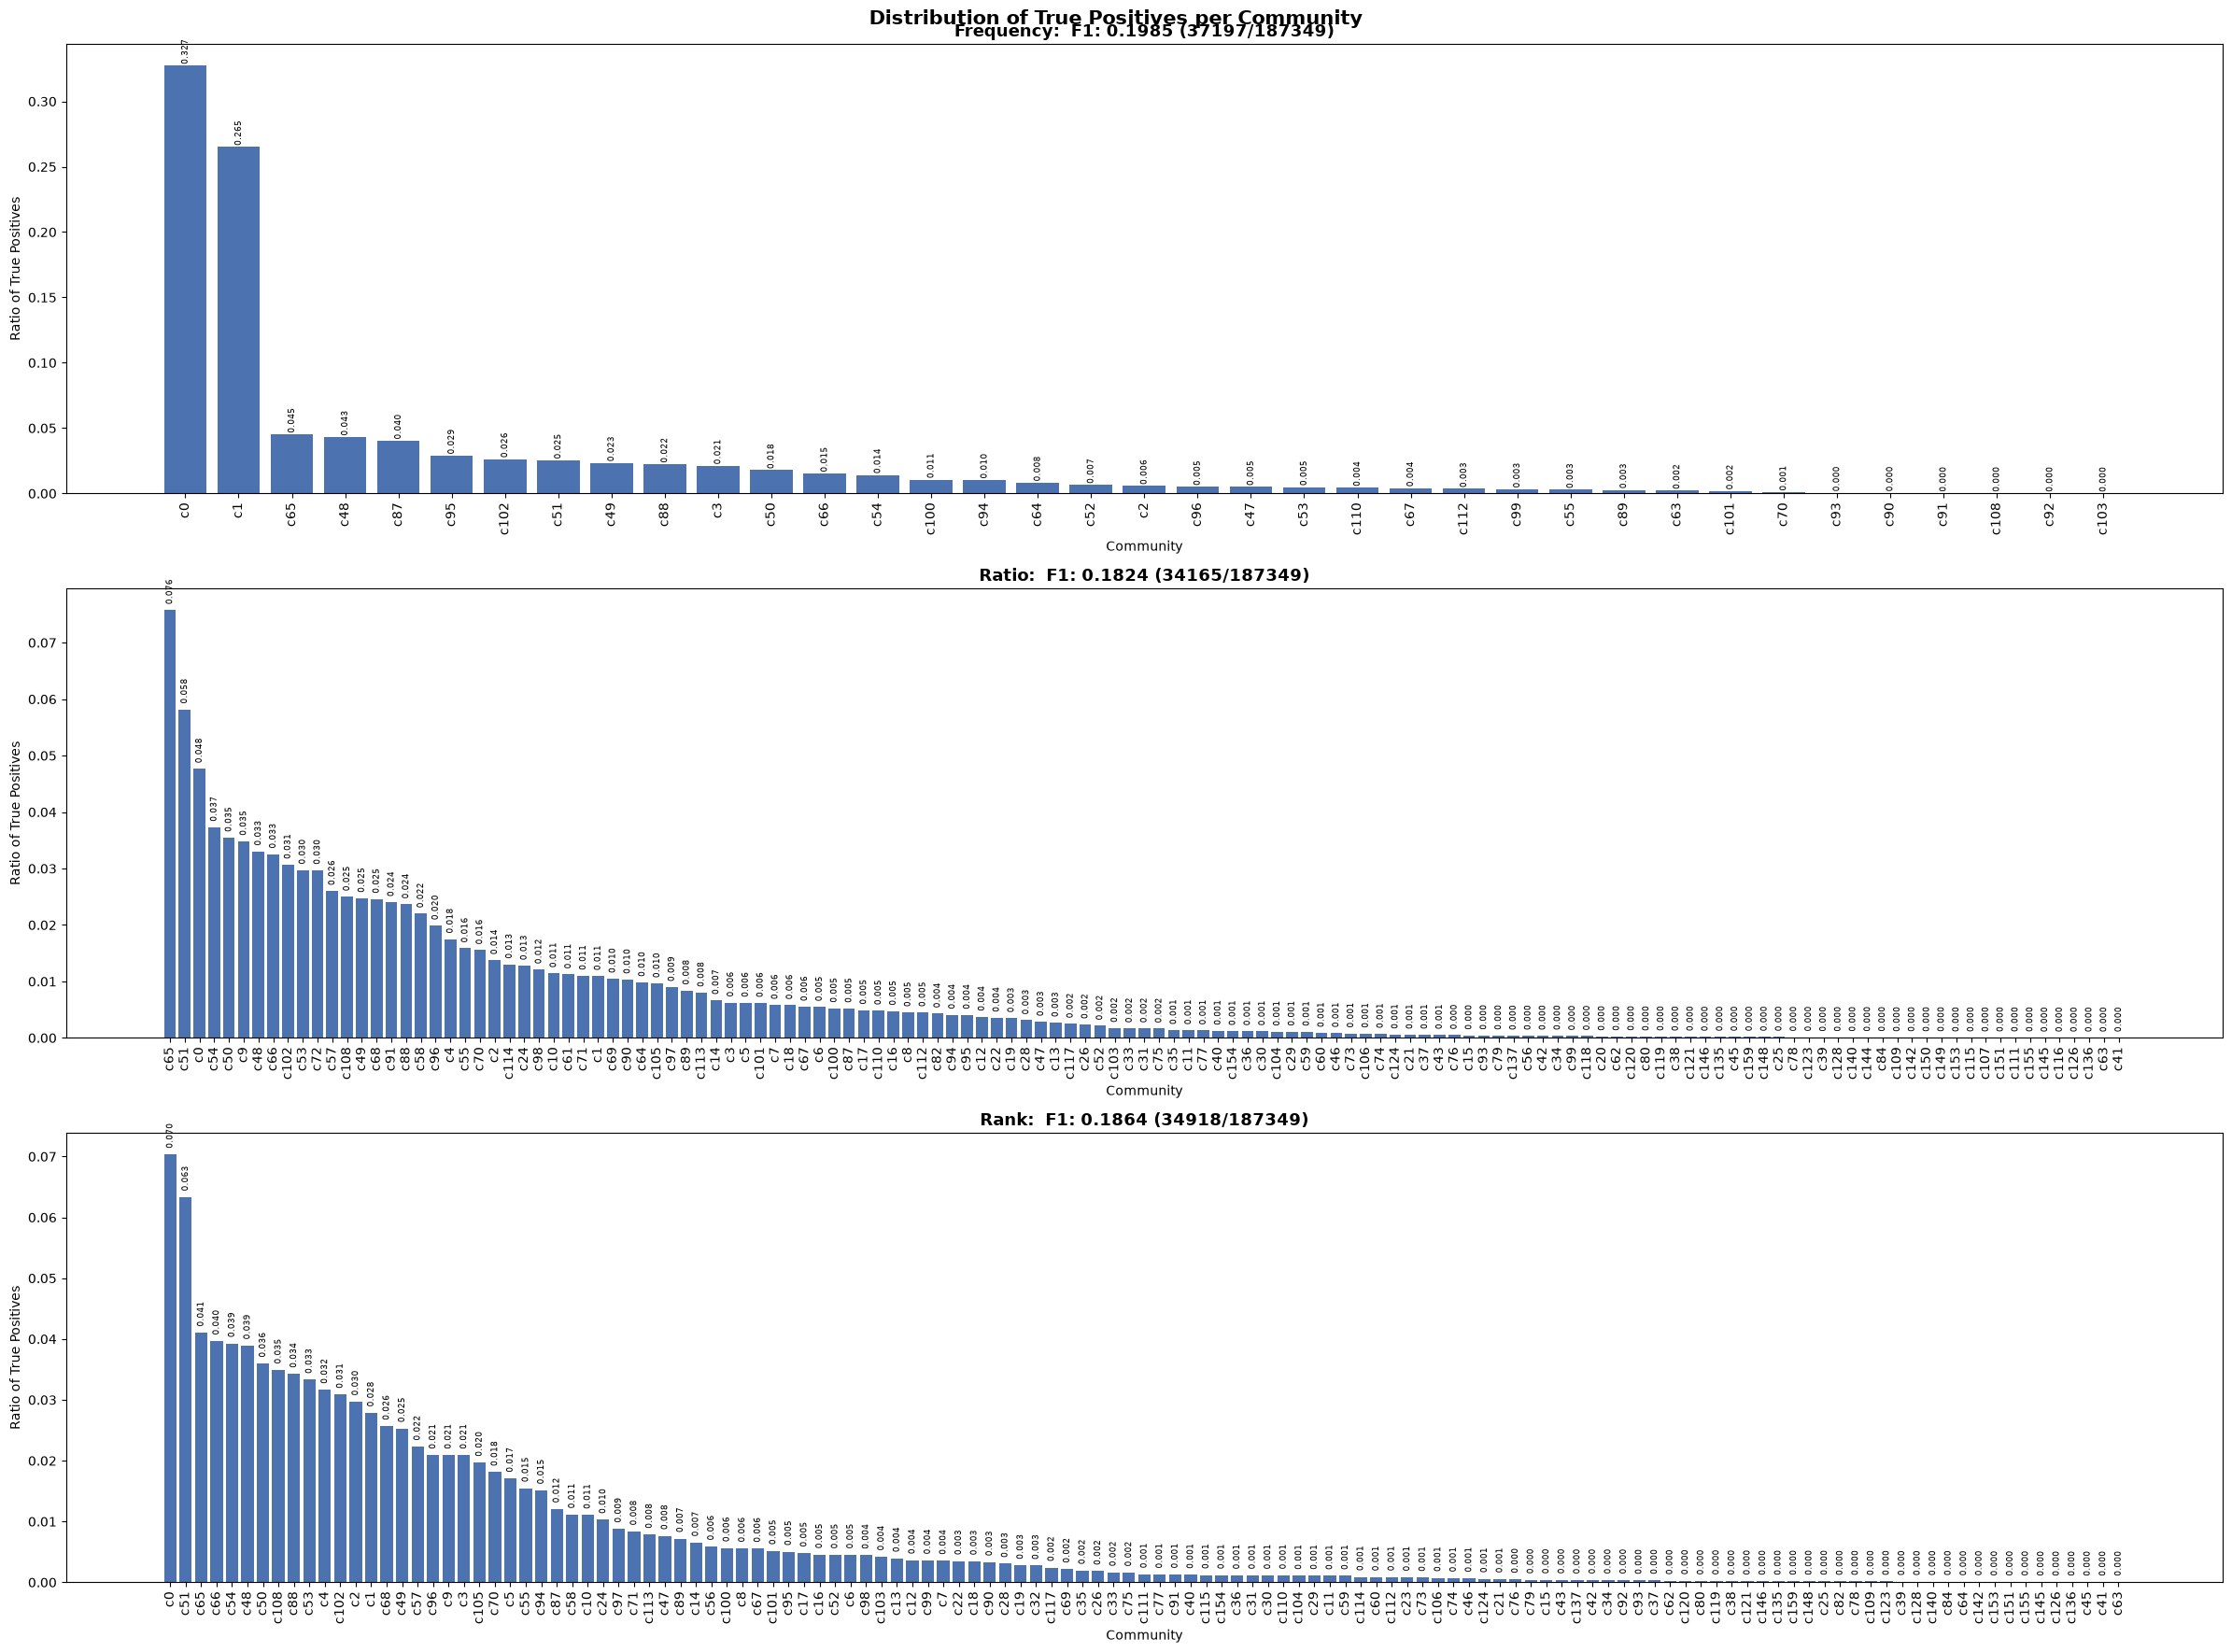

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

evaluation = pd.read_csv(ROOT_VECTOR_COMPARISON_DIR + 'evaluation_results.csv.gz', compression="gzip")

fig, axes = plt.subplots(3, 1, figsize=(24, 18))

for ax, (metric, is_best_col, best_community_col) in zip(axes, [
    ('Frequency', 'is_best_freq',  'best_comm_freq'),
    ('Ratio',     'is_best_ratio', 'best_comm_ratio'),
    ('Rank',      'is_best_rank',  'best_comm_rank'),
]):
    correct_df = evaluation[evaluation[is_best_col] == True]
    community_counts = correct_df[best_community_col].value_counts()
    community_ratios = (community_counts / len(correct_df)).sort_values(ascending=False)

    labels = [f"c{int(c)}" for c in community_ratios.index]

    bars = ax.bar(labels, community_ratios.values, color='#4C72B0')

    ax.set_title(f'{metric}:  F1: {len(correct_df)/len(evaluation):.4f} ({int(len(correct_df))}/{len(evaluation)})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Community')
    ax.set_ylabel('Ratio of True Positives')
    ax.tick_params(axis='x', rotation=90)

    for bar, val in zip(bars, community_ratios.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

plt.suptitle('Distribution of True Positives per Community', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT_FIGURES_DIR + 'true_positive_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

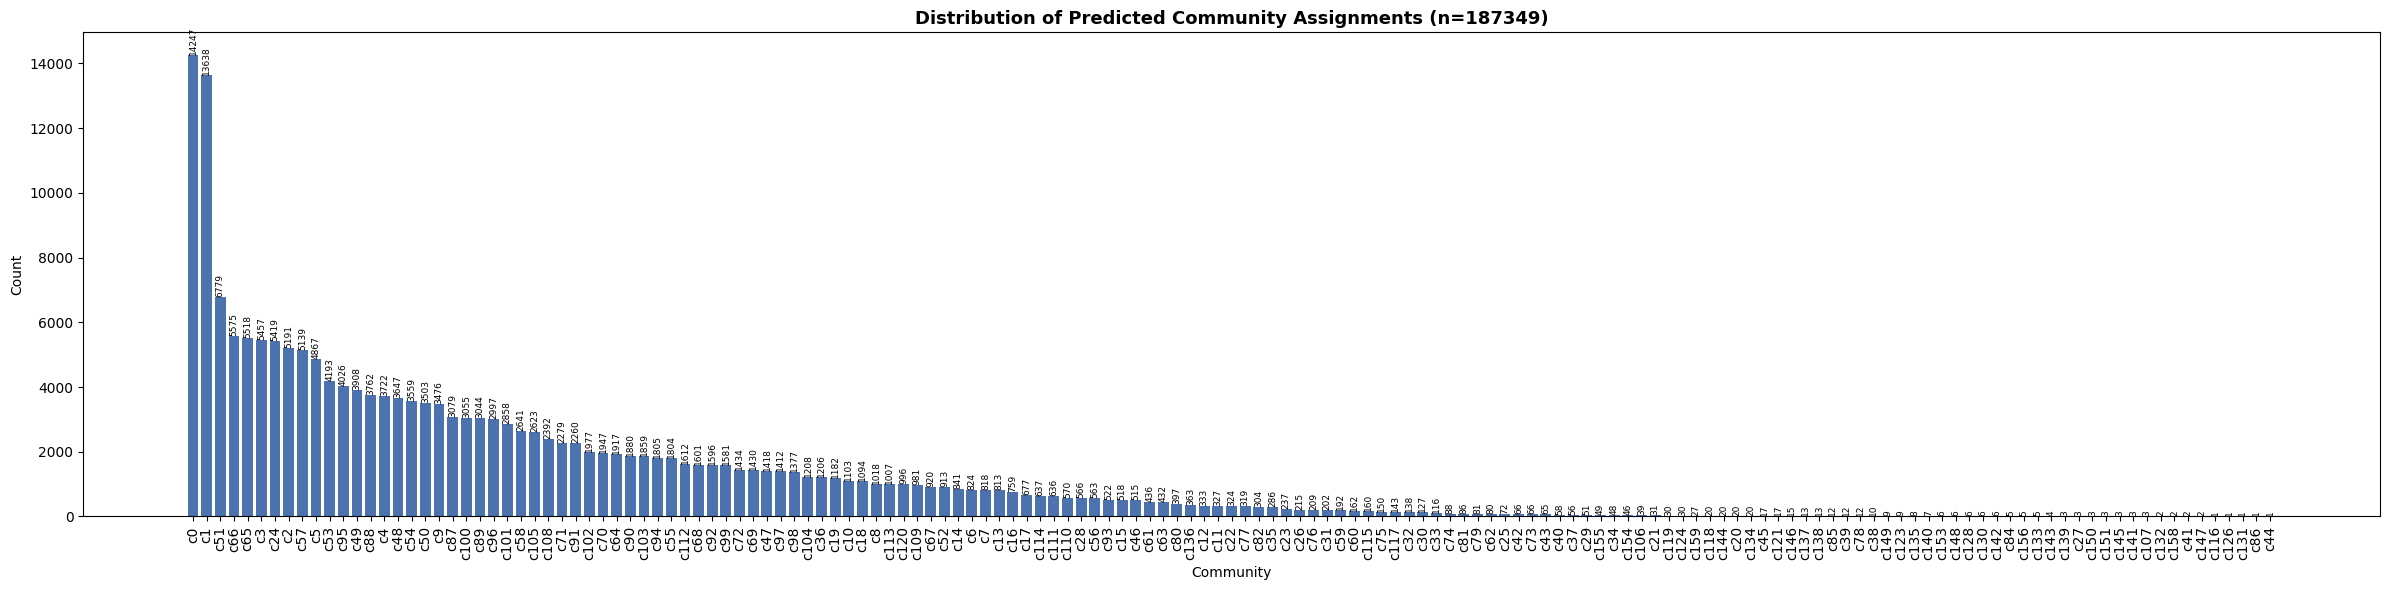

In [ ]:
fig, ax = plt.subplots(figsize=(24, 6))

community_counts = evaluation['predicted_community'].value_counts().sort_values(ascending=False)
labels = [f"c{int(c)}" for c in community_counts.index]

bars = ax.bar(labels, community_counts.values, color='#4C72B0')

ax.set_title(f'Distribution of Predicted Community Assignments (n={len(evaluation)})', fontsize=13, fontweight='bold')
ax.set_xlabel('Community')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90)

for bar, val in zip(bars, community_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val}', ha='center', va='bottom', fontsize=6.5, rotation=90)

plt.tight_layout()
plt.savefig(ROOT_FIGURES_DIR + 'predicted_assignment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

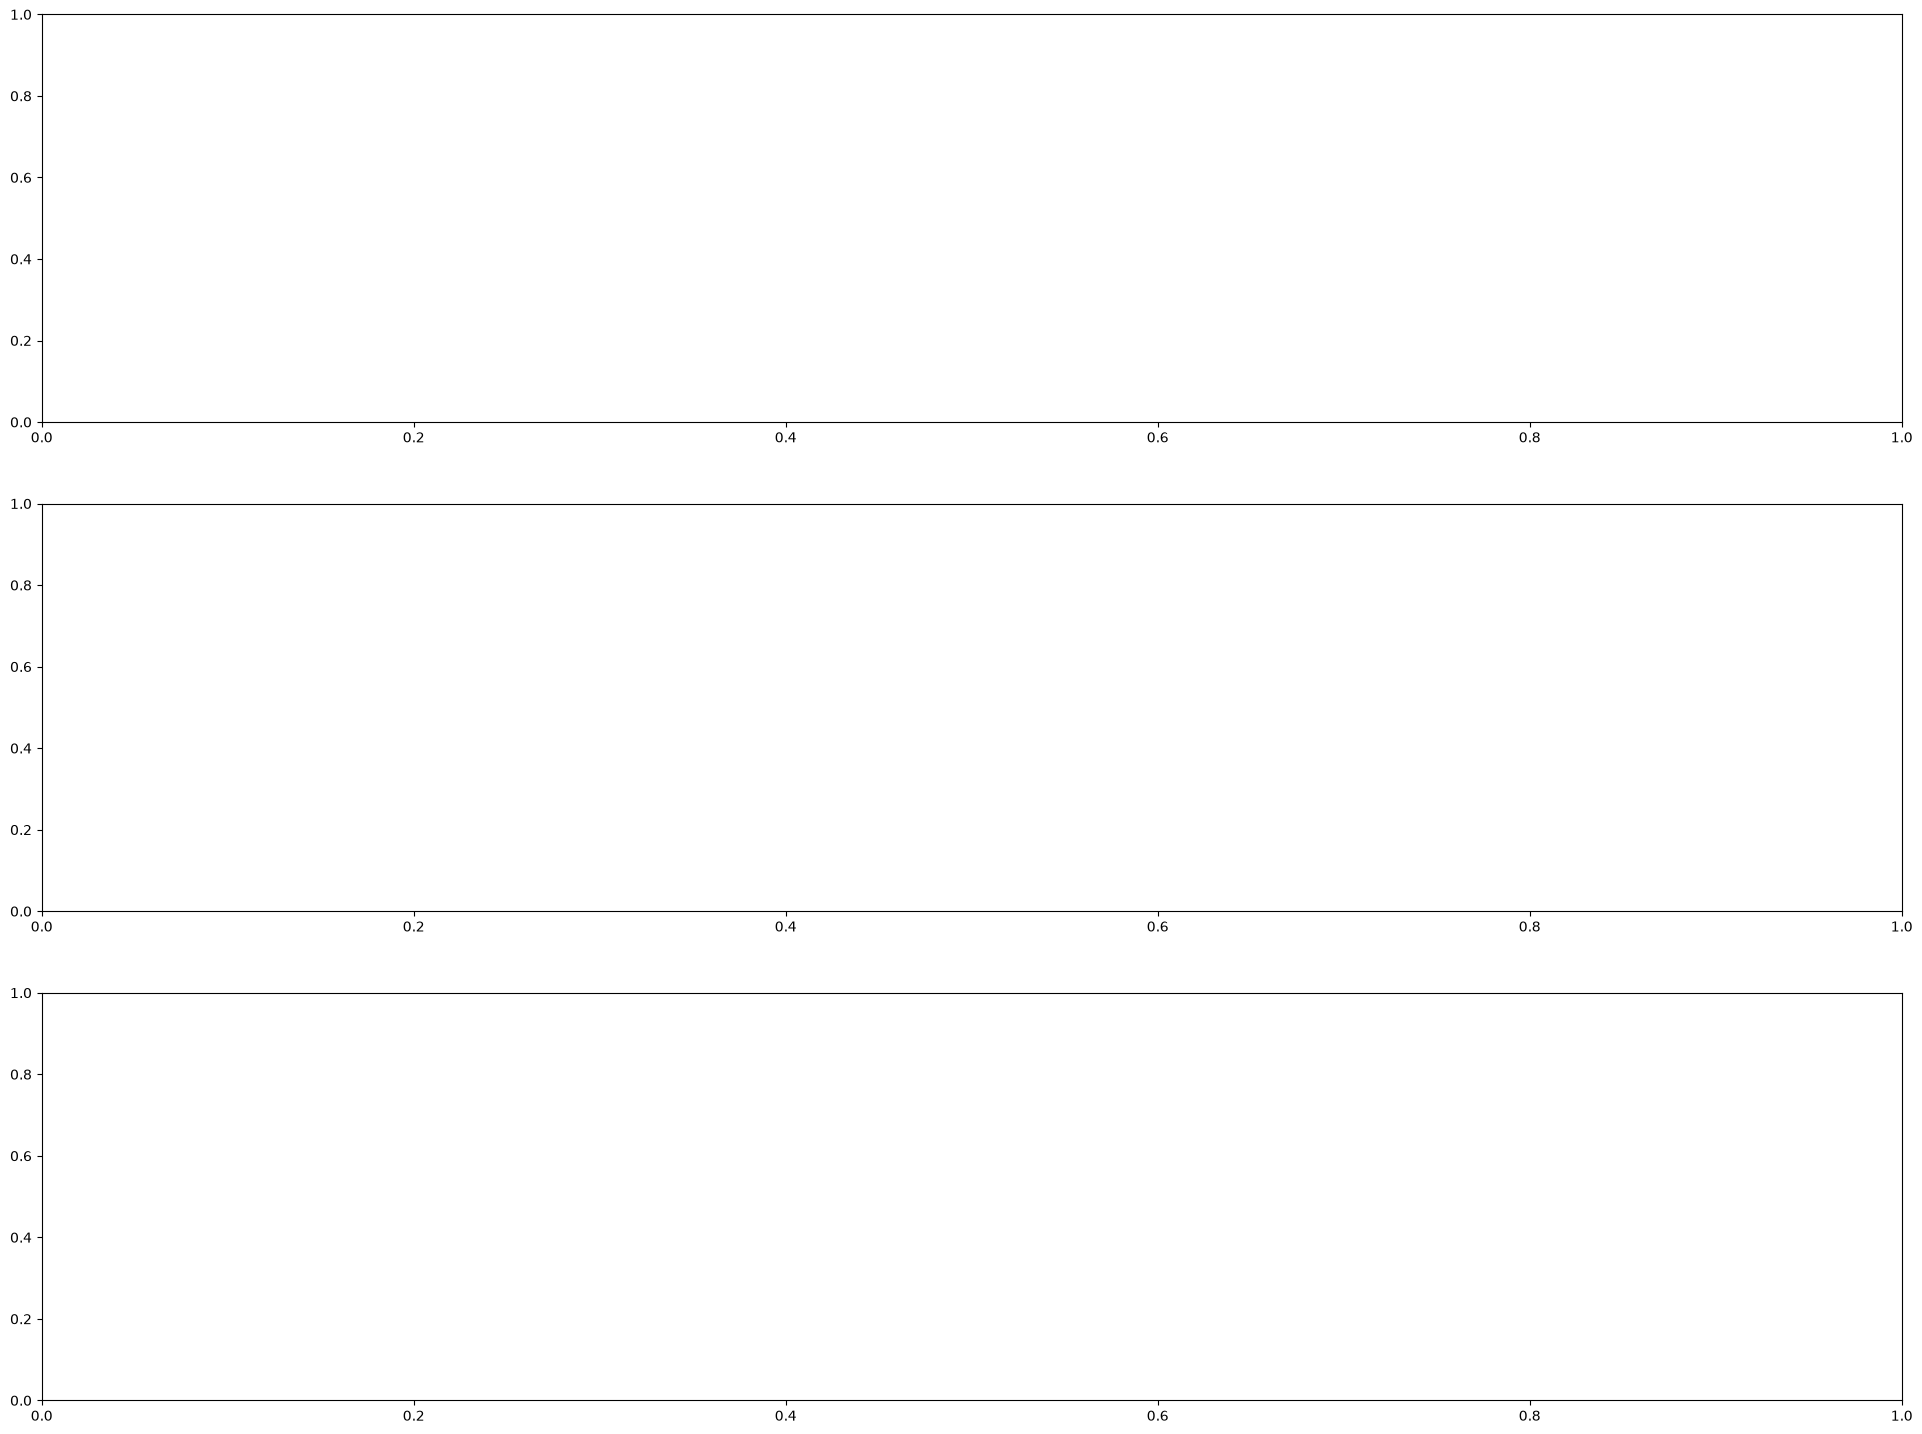

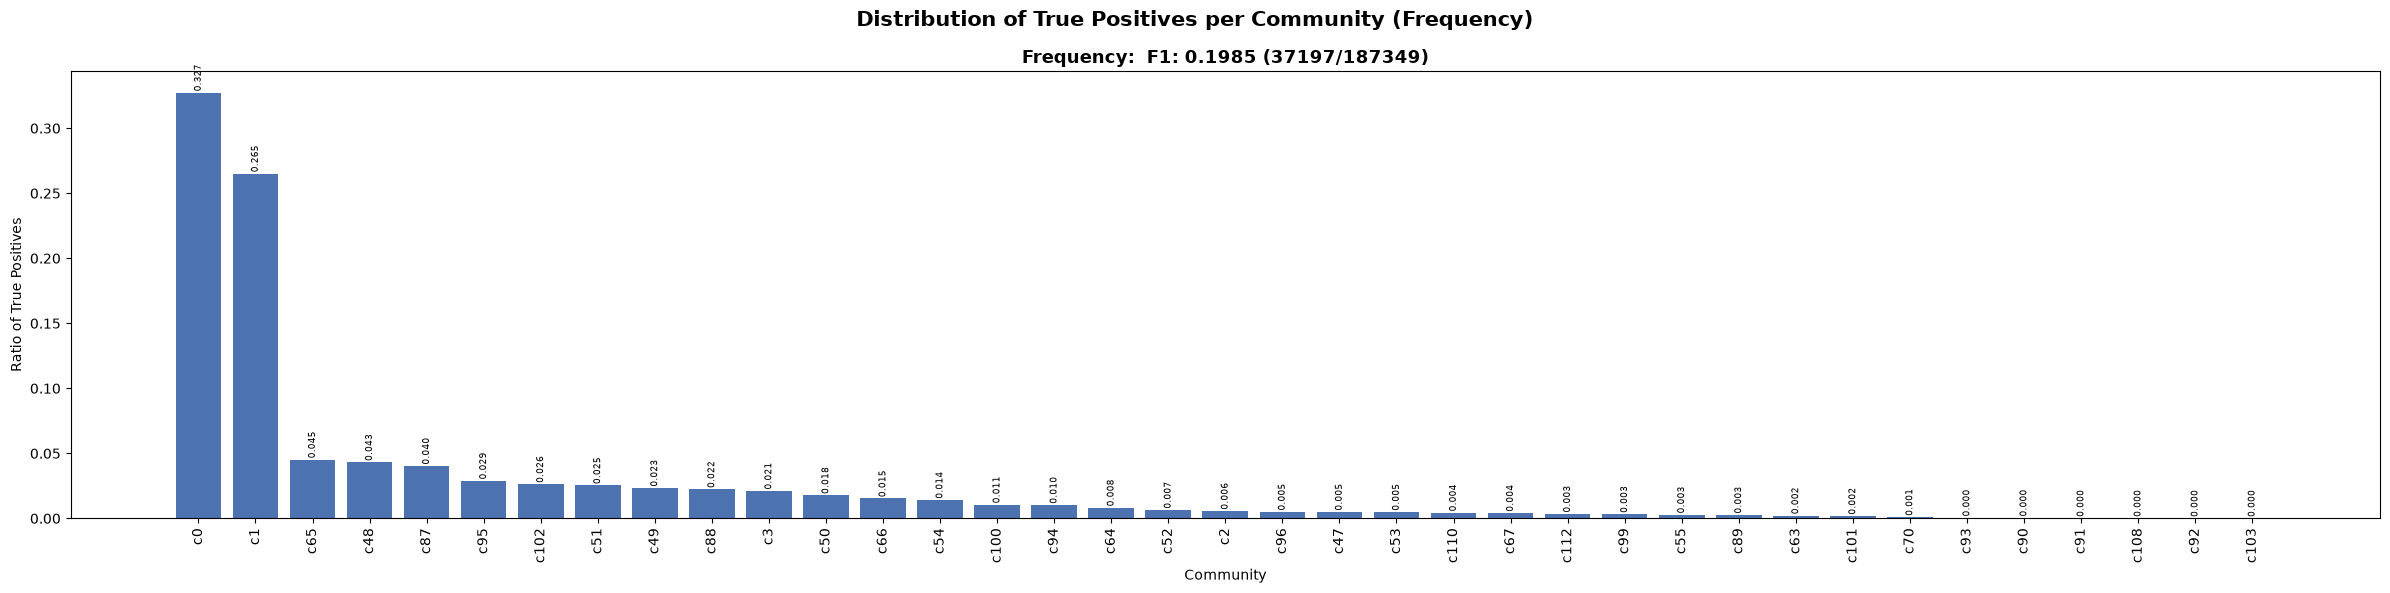

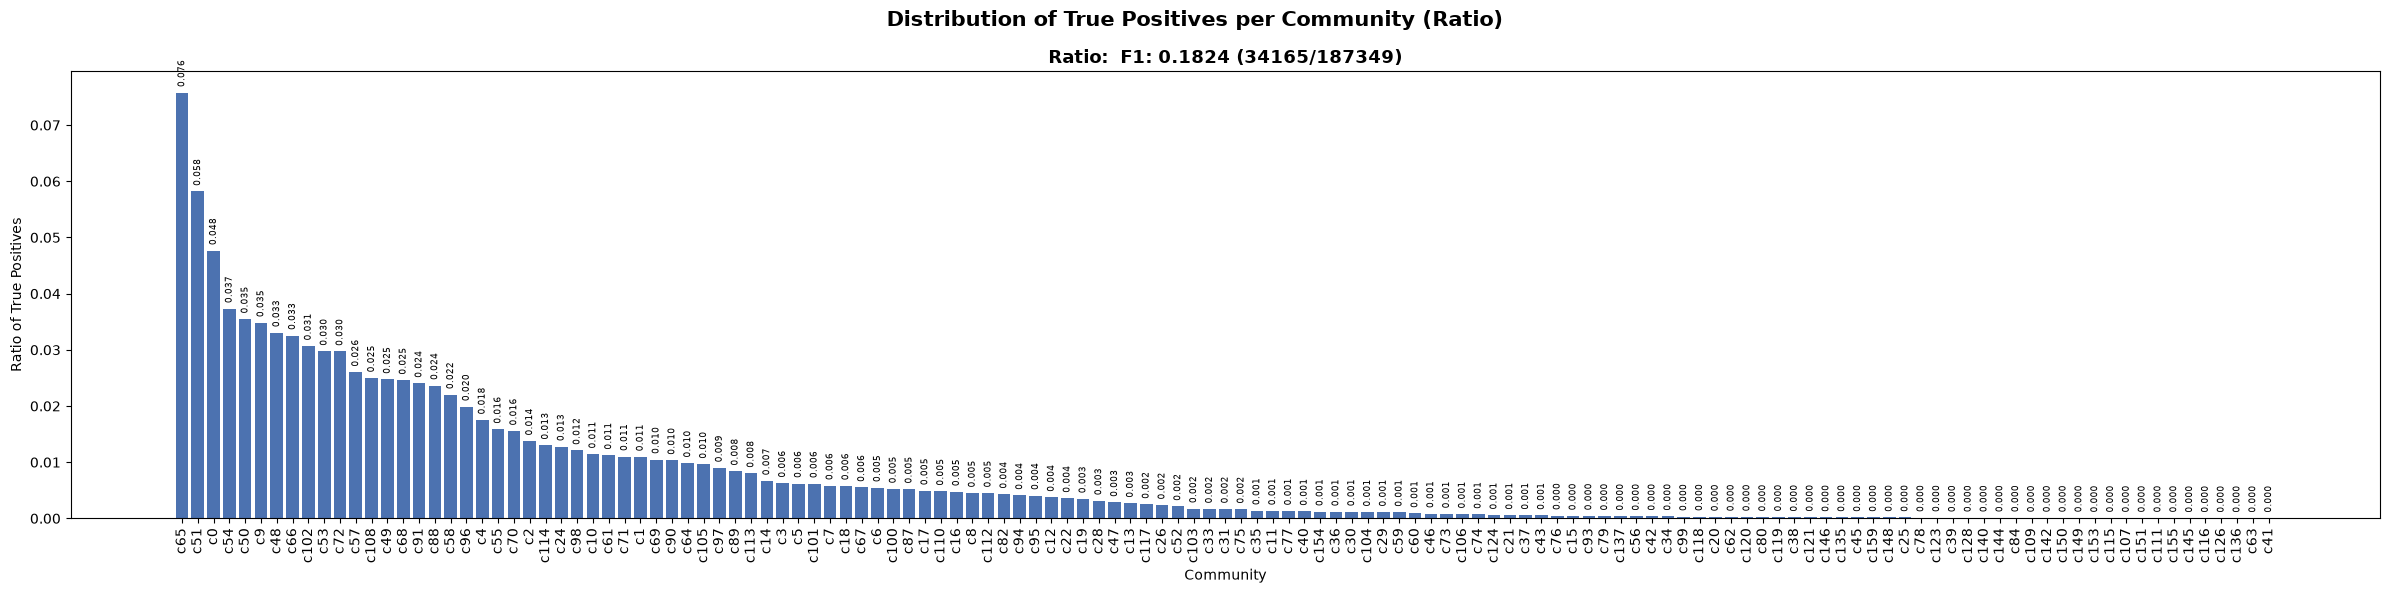

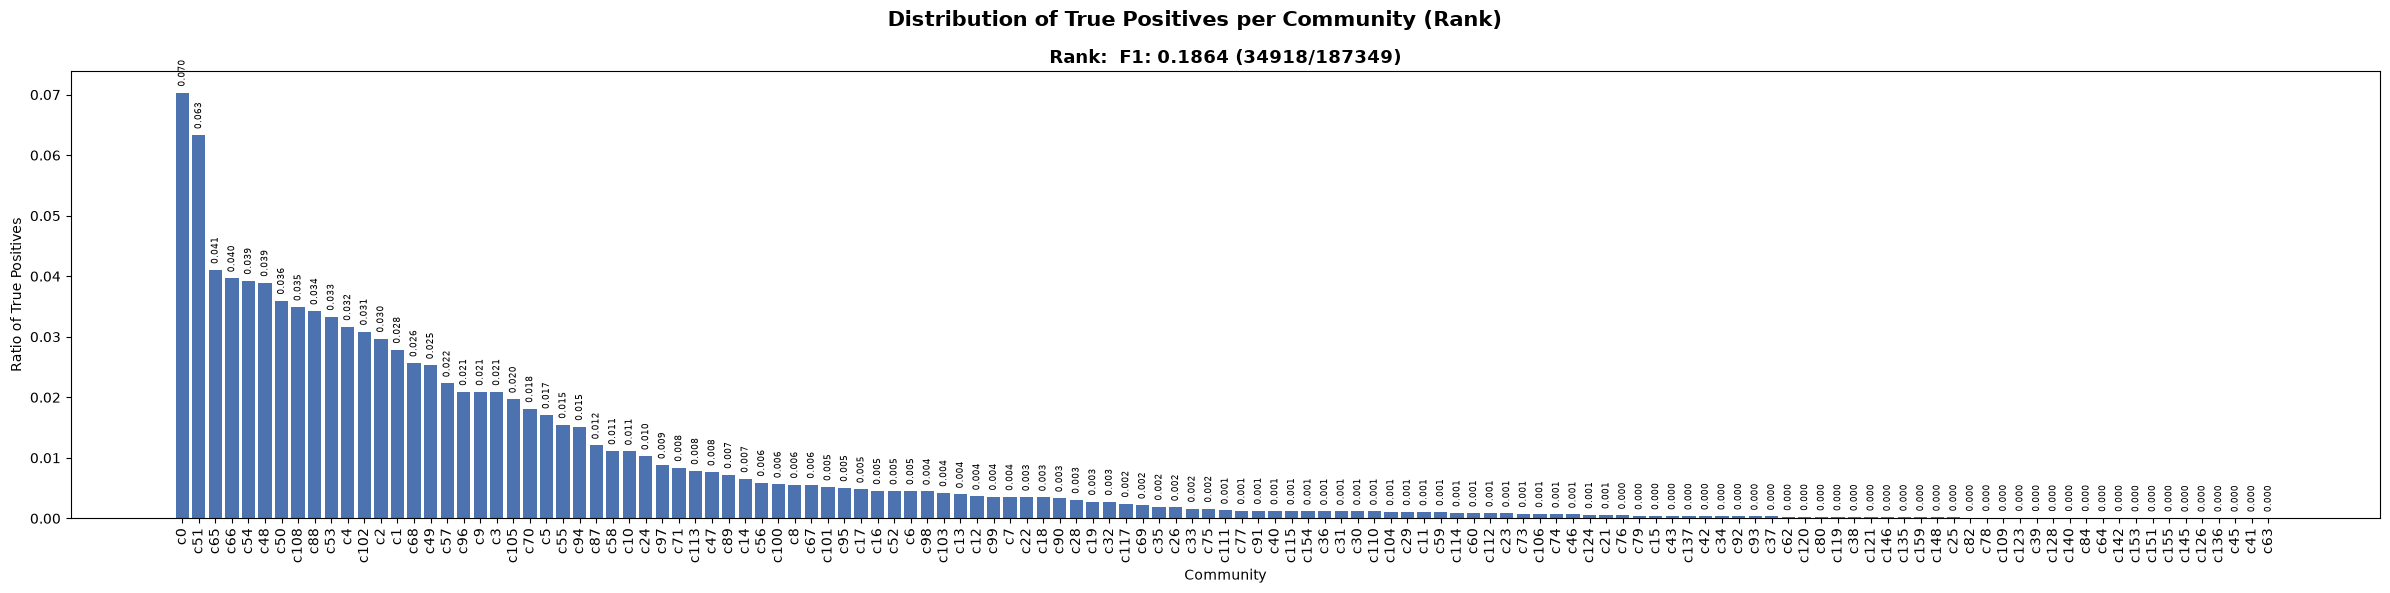

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

evaluation = pd.read_csv(ROOT_VECTOR_COMPARISON_DIR + 'evaluation_results.csv.gz', compression="gzip")

fig, axes = plt.subplots(3, 1, figsize=(24, 18))

metrics = [
    ('Frequency', 'is_best_freq', 'best_comm_freq', 'frequency'),
    ('Ratio',     'is_best_ratio', 'best_comm_ratio', 'ratio'),
    ('Rank',      'is_best_rank',  'best_comm_rank', 'rank'),
]

for metric, is_best_col, best_community_col, file_name in metrics:
    fig, ax = plt.subplots(figsize=(24, 6))

    correct_df = evaluation[evaluation[is_best_col] == True]
    community_counts = correct_df[best_community_col].value_counts()
    community_ratios = (community_counts / len(correct_df)).sort_values(ascending=False)
    labels = [f"c{int(c)}" for c in community_ratios.index]

    bars = ax.bar(labels, community_ratios.values, color='#4C72B0')

    ax.set_title(f'{metric}:  F1: {len(correct_df)/len(evaluation):.4f} ({int(len(correct_df))}/{len(evaluation)})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Community')
    ax.set_ylabel('Ratio of True Positives')
    ax.tick_params(axis='x', rotation=90)

    for bar, val in zip(bars, community_ratios.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

    plt.suptitle(f'Distribution of True Positives per Community ({metric})', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(ROOT_FIGURES_DIR + f'true_positive_distribution_{file_name}.png', dpi=150, bbox_inches='tight')
    plt.show()